In [1]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [3]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [4]:
train_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )

])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )

])

In [5]:
train_dataset = CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)

In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = test_transform

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [8]:
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

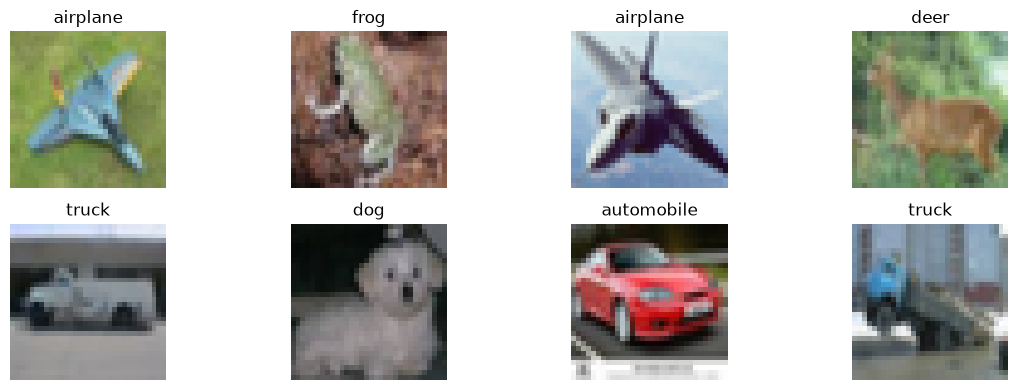

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i] / 2 + 0.5

    img = img.permute(1,2,0)

    plt.imshow(img)

    plt.title(classes[labels[i]])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [10]:
class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128*4*4,256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,10)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [11]:
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
best_val_accuracy = 0

num_epochs = 20

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # ==========================
    # Training
    # ==========================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ==========================
    # Validation
    # ==========================

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "models/best_model.pth"
        )

print("\nTraining Finished!")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

Epoch [1/20] | Train Loss: 1.5639 | Train Acc: 0.4271 | Val Loss: 1.2350 | Val Acc: 0.5456
Epoch [2/20] | Train Loss: 1.1915 | Train Acc: 0.5728 | Val Loss: 1.0492 | Val Acc: 0.6210
Epoch [3/20] | Train Loss: 0.9938 | Train Acc: 0.6506 | Val Loss: 0.8714 | Val Acc: 0.6874
Epoch [4/20] | Train Loss: 0.8698 | Train Acc: 0.6980 | Val Loss: 0.8033 | Val Acc: 0.7225
Epoch [5/20] | Train Loss: 0.7684 | Train Acc: 0.7327 | Val Loss: 0.8135 | Val Acc: 0.7136
Epoch [6/20] | Train Loss: 0.6874 | Train Acc: 0.7593 | Val Loss: 0.7142 | Val Acc: 0.7508
Epoch [7/20] | Train Loss: 0.6200 | Train Acc: 0.7833 | Val Loss: 0.7044 | Val Acc: 0.7550
Epoch [8/20] | Train Loss: 0.5638 | Train Acc: 0.8038 | Val Loss: 0.7167 | Val Acc: 0.7552
Epoch [9/20] | Train Loss: 0.5175 | Train Acc: 0.8184 | Val Loss: 0.7269 | Val Acc: 0.7554
Epoch [10/20] | Train Loss: 0.4626 | Train Acc: 0.8342 | Val Loss: 0.7277 | Val Acc: 0.7573
Epoch [11/20] | Train Loss: 0.4240 | Train Acc: 0.8483 | Val Loss: 0.7875 | Val Acc: 0.75

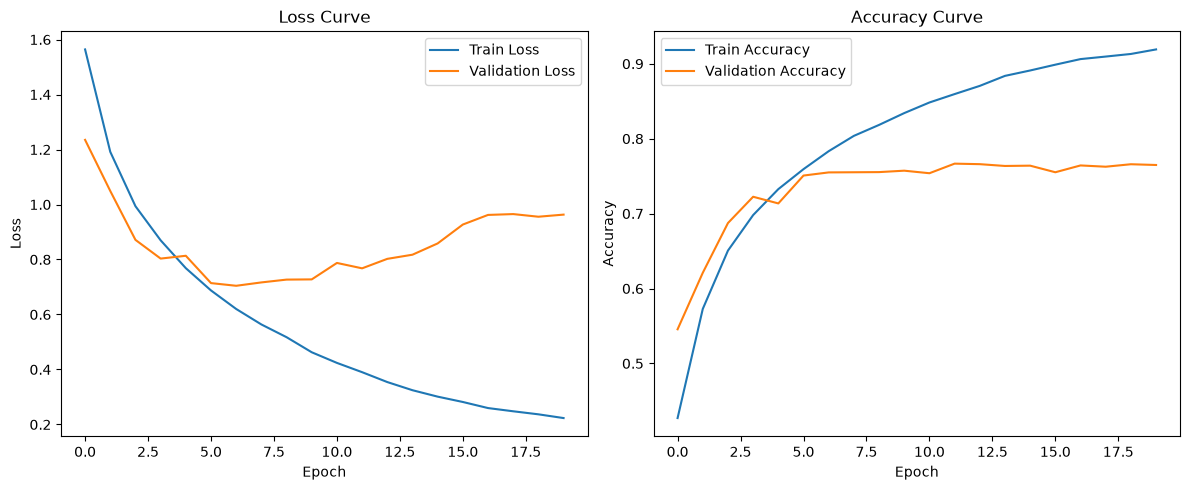

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()

plt.show()

In [14]:
model.load_state_dict(
    torch.load("models/best_model.pth")
)

model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [15]:
predictions = []
targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())
        targets.extend(labels.cpu().numpy())

In [16]:
accuracy = accuracy_score(
    targets,
    predictions
)

precision = precision_score(
    targets,
    predictions,
    average="macro"
)

recall = recall_score(
    targets,
    predictions,
    average="macro"
)

f1 = f1_score(
    targets,
    predictions,
    average="macro"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7607
Precision: 0.7610
Recall   : 0.7607
F1 Score : 0.7598


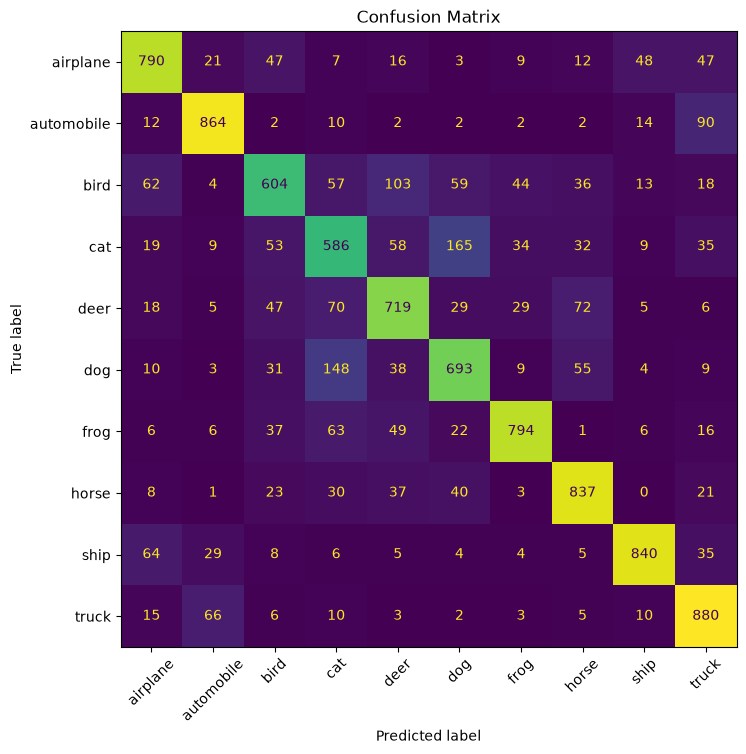

In [17]:
cm = confusion_matrix(
    targets,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.show()

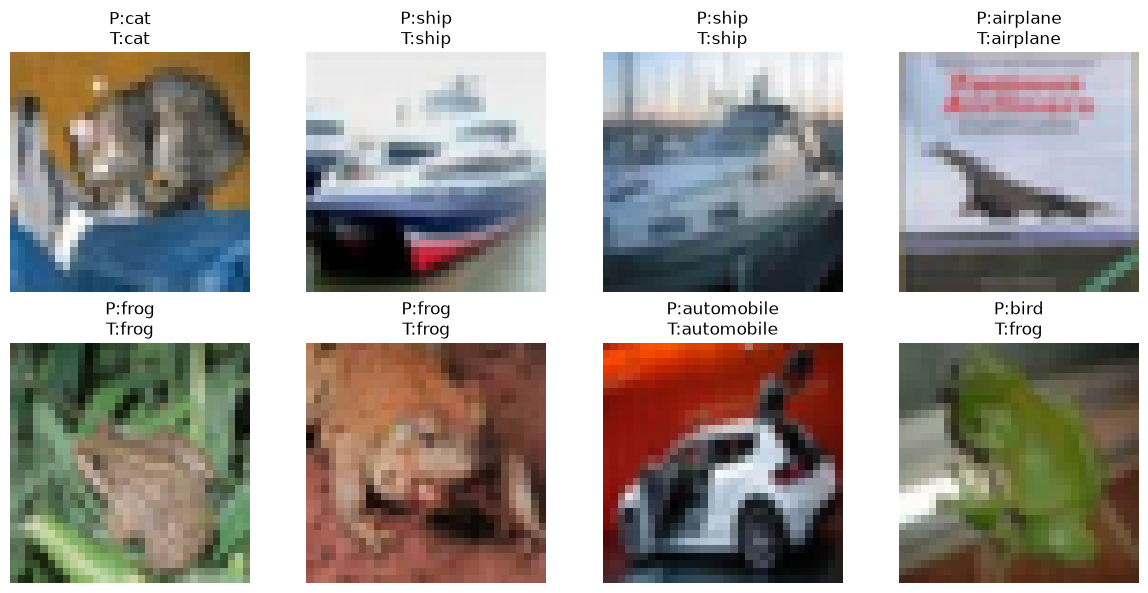

In [18]:
images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(images)

_, predicted = torch.max(outputs,1)

plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i].cpu()

    img = img * 0.5 + 0.5

    img = img.permute(1,2,0)

    plt.imshow(img)

    plt.title(
        f"P:{classes[predicted[i]]}\nT:{classes[labels[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [19]:
torch.save(
    model.state_dict(),
    "models/final_model.pth"
)

print("Final model saved successfully!")

Final model saved successfully!


In [20]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 620,362
Trainable Parameters : 620,362


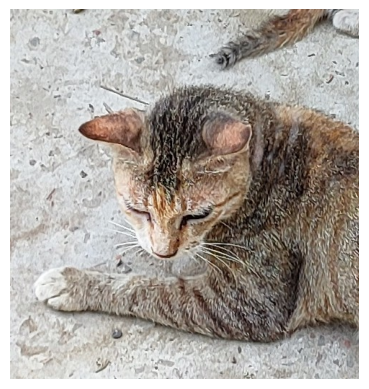

Prediction : cat
Confidence : 57.39%


In [37]:
from PIL import Image
import torch.nn.functional as F

image_path = "../sample_images/img2.jpg"

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.show()

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    output = model(input_tensor)

    probabilities = F.softmax(output, dim=1)

    confidence, predicted = torch.max(probabilities, 1)

print(f"Prediction : {classes[predicted.item()]}")
print(f"Confidence : {confidence.item()*100:.2f}%")